<a href="https://colab.research.google.com/github/viniciuscristall-spec/CP02-MLAM-REGRESSAO-LINEAR/blob/main/PIB_x_ABCR_regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PIB x Fluxo de veículos pedagiados (ABCR): existe relação e dá para prever?

**Objetivo.** Verificar se a atividade econômica do Brasil (PIB) anda junto com o fluxo de veículos nas rodovias pedagiadas (Índice ABCR) e testar se uma **regressão linear simples** consegue estimar o fluxo de veículos a partir do PIB.

**Fontes de dados**
- **PIB:** índice de volume trimestral do IBGE/SIDRA (tabela 1620, base: média de 1995 = 100).
- **Fluxo de veículos:** Índice ABCR mensal, série original, sem ajuste sazonal (base: 1999 = 100).

**Roteiro do notebook**
1. Carregamento dos dados
2. Tratamento e construção da tabela anual
3. Análise de correlação
4. Treinamento do modelo
5. Avaliação dos resultados
6. Conclusões
7. Dificuldades encontradas e soluções

## Configuração do ambiente

Bibliotecas usadas: `pandas` e `numpy` para os dados, `matplotlib` para os gráficos, `scikit-learn` para o modelo e as métricas, e `openpyxl` para ler a planilha da ABCR.

In [ ]:
import csv
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Parte 1: Carregamento dos dados

Os dois arquivos de entrada são `tabela1620.csv` (PIB) e `abcr_0826.xlsx` (ABCR). A função abaixo tenta, nesta ordem:

1. usar o arquivo se ele já estiver na pasta do notebook;
2. baixá-lo do repositório do grupo no GitHub;
3. pedir o upload manual (funciona no Google Colab).

Assim o notebook roda sem erro de "arquivo não encontrado", seja no Colab ou na máquina local.

In [ ]:
BASE_URL = "https://raw.githubusercontent.com/viniciuscristall-spec/CP02_ML/refs/heads/main/"

ARQ_PIB  = "tabela1620.csv"
ARQ_ABCR = "abcr_0826.xlsx"


def obter_arquivo(nome, url):
    """Garante que o arquivo exista localmente: usa o existente, baixa ou pede upload."""
    if os.path.exists(nome):
        print(f"[ok] {nome} encontrado na pasta atual.")
        return nome
    try:
        urllib.request.urlretrieve(url, nome)
        print(f"[ok] {nome} baixado do GitHub.")
        return nome
    except Exception as erro:
        print(f"[aviso] não foi possível baixar {nome} ({erro}).")
    try:
        from google.colab import files  # só existe no Colab
        print(f"Selecione o arquivo {nome} no seu computador:")
        enviado = next(iter(files.upload()))
        if enviado != nome:
            os.replace(enviado, nome)
        return nome
    except ImportError:
        raise FileNotFoundError(
            f"Coloque o arquivo '{nome}' na mesma pasta do notebook e execute novamente."
        )


obter_arquivo(ARQ_PIB, BASE_URL + ARQ_PIB)
obter_arquivo(ARQ_ABCR, BASE_URL + ARQ_ABCR)

[aviso] não foi possível baixar tabela1620.csv (HTTP Error 404: Not Found).
Selecione o arquivo tabela1620.csv no seu computador:


Saving tabela1620.csv to tabela1620.csv
[aviso] não foi possível baixar abcr_0826.xlsx (HTTP Error 404: Not Found).
Selecione o arquivo abcr_0826.xlsx no seu computador:


Saving abcr_0826.xlsx to abcr_0826.xlsx
Saving abcr_mensal_brasil.csv to abcr_mensal_brasil.csv
Saving base_anual.csv to base_anual.csv
Saving pib_trimestral.csv to pib_trimestral.csv
Saving tabela1620.csv to tabela1620 (1).csv


'abcr_0826.xlsx'

## Parte 2: Tratamento e construção da tabela anual

As duas séries têm **frequências diferentes**: o PIB é trimestral e a ABCR é mensal. Para compará-las, transformamos as duas em **média anual**.

Passos desta parte:
1. Ler a linha "Brasil" do CSV do SIDRA (que vem transposto, com trimestres em colunas) e montar uma série de PIB por trimestre.
2. Ler a aba `(C) Original` da planilha da ABCR (série sem ajuste sazonal) e montar uma série mensal.
3. Calcular a média por ano em cada série e manter **apenas anos completos** (4 trimestres e 12 meses), para não distorcer a média.
4. Juntar tudo em uma tabela com uma linha por ano (`Ano`, `PIB_indice`, `ABCR_indice`) e salvar em `pib_abcr_anual.csv`.

In [ ]:
ABA_ABCR = "(C) Original"
COL_ABCR = 3  # coluna do Índice ABCR (Brasil / Total)

# --- PIB trimestral (CSV do SIDRA) ---
with open(ARQ_PIB, encoding="utf-8-sig") as f:
    linhas = list(csv.reader(f, delimiter=";"))

cabecalho = next(r for r in linhas if len(r) > 5 and "trimestre" in r[1])
valores   = next(r for r in linhas if r and r[0] == "Brasil")

pib = pd.DataFrame({
    "periodo": cabecalho[1:],
    "valor": [float(x.replace(",", ".")) for x in valores[1:]],
})
pib["Ano"] = pib["periodo"].str.extract(r"(\d{4})").astype(int)
pib_ano = pib.groupby("Ano")["valor"].agg(n="count", media="mean")

# --- ABCR mensal (planilha Excel) ---
ws = openpyxl.load_workbook(ARQ_ABCR, data_only=True)[ABA_ABCR]
dados = [(r[0].value, r[COL_ABCR].value)
         for r in ws.iter_rows(min_row=4)
         if hasattr(r[0].value, "year") and r[COL_ABCR].value is not None]

abcr = pd.DataFrame(dados, columns=["data", "valor"])
abcr["Ano"] = abcr["data"].dt.year
abcr_ano = abcr.groupby("Ano")["valor"].agg(n="count", media="mean")

# --- Verificações de qualidade ---
print("Anos PIB sem 4 trimestres:", pib_ano[pib_ano.n != 4].index.tolist())
print("Anos ABCR sem 12 meses   :", abcr_ano[abcr_ano.n != 12].index.tolist())
print("Meses duplicados na ABCR :", abcr["data"].duplicated().sum())

# --- Anos completos nas duas séries ---
ANO_INICIO, ANO_FIM = 2006, 2025  # janela de análise do trabalho
anos = sorted(a for a in (set(pib_ano.index[pib_ano.n == 4]) &
                          set(abcr_ano.index[abcr_ano.n == 12]))
              if ANO_INICIO <= a <= ANO_FIM)

df = pd.DataFrame({
    "Ano": anos,
    "PIB_indice":  pib_ano.loc[anos, "media"].values,
    "ABCR_indice": abcr_ano.loc[anos, "media"].values,
}).round(2)

assert df.notna().all().all(), "Há valores nulos na tabela anual."
print(f"\nTabela anual: {len(df)} anos ({df['Ano'].min()}-{df['Ano'].max()})")
print(df.to_string(index=False))

df.to_csv("pib_abcr_anual.csv", index=False,
          sep=";", decimal=",", encoding="utf-8-sig")

Anos PIB sem 4 trimestres: []
Anos ABCR sem 12 meses   : [2026]
Meses duplicados na ABCR : 0

Tabela anual: 20 anos (2006-2025)
 Ano  PIB_indice  ABCR_indice
2006      133.35       107.49
2007      141.45       113.99
2008      148.65       120.91
2009      148.47       123.60
2010      159.64       133.12
2011      165.98       141.44
2012      169.18       147.97
2013      174.26       153.59
2014      175.14       157.23
2015      168.93       154.25
2016      163.39       148.91
2017      165.56       151.36
2018      168.51       150.12
2019      170.56       155.34
2020      164.98       133.81
2021      172.83       144.99
2022      178.05       154.12
2023      183.82       163.49
2024      190.10       168.88
2025      194.45       173.12


## Parte 3: Análise de correlação

Antes de modelar, medimos o quanto as duas séries andam juntas:

- **Pearson (níveis):** força da relação linear entre os índices anuais.
- **Spearman:** mesma ideia, mas baseada em posições (ranking), menos sensível a valores extremos.
- **Pearson sem 2020:** testa se o ano da pandemia, que foge do padrão, está distorcendo o resultado.
- **Pearson das variações anuais:** correlação entre as taxas de crescimento, que remove o efeito de "os dois índices subirem com o tempo".

Em seguida, o gráfico de dispersão mostra cada ano como um ponto, com a reta de ajuste.

Pearson (níveis)           : 0.964
R²                         : 0.930
Spearman (níveis)          : 0.907
Pearson sem 2020           : 0.971
Pearson (variações anuais) : 0.825
Reta de ajuste             : ABCR = 1.123 * PIB + -42.48


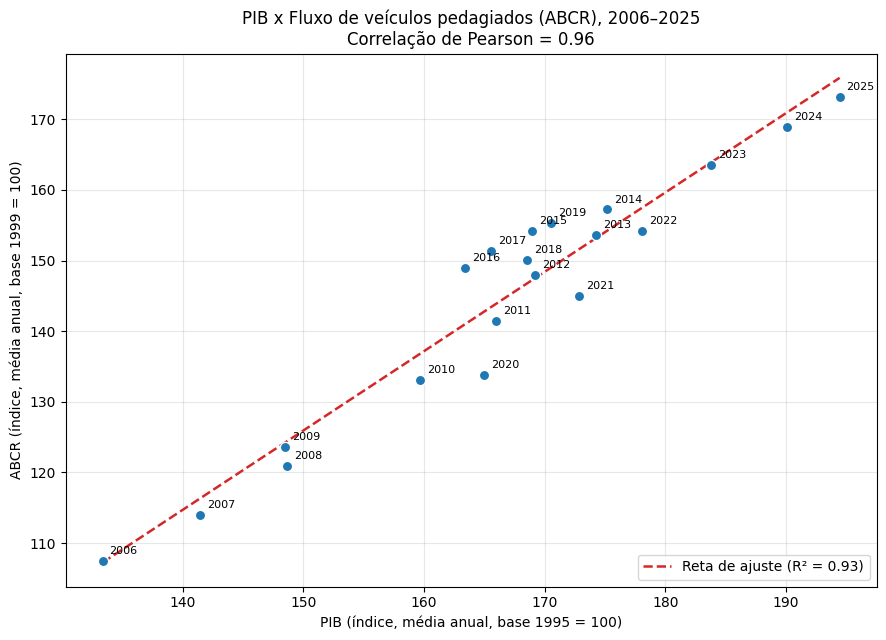

In [ ]:
x, y = df["PIB_indice"], df["ABCR_indice"]

pearson  = x.corr(y)
spearman = x.corr(y, method="spearman")
a_reta, b_reta = np.polyfit(x, y, 1)
r2_pearson = pearson ** 2

sem2020 = df[df["Ano"] != 2020]
pearson_sem2020 = sem2020["PIB_indice"].corr(sem2020["ABCR_indice"])

var = df.set_index("Ano")[["PIB_indice", "ABCR_indice"]].pct_change().dropna()
pearson_var = var["PIB_indice"].corr(var["ABCR_indice"])

print(f"Pearson (níveis)           : {pearson:.3f}")
print(f"R²                         : {r2_pearson:.3f}")
print(f"Spearman (níveis)          : {spearman:.3f}")
print(f"Pearson sem 2020           : {pearson_sem2020:.3f}")
print(f"Pearson (variações anuais) : {pearson_var:.3f}")
print(f"Reta de ajuste             : ABCR = {a_reta:.3f} * PIB + {b_reta:.2f}")

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(x, y, s=55, color="#1f77b4", edgecolor="white", zorder=3)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a_reta * xs + b_reta, color="#d62728", lw=1.8, ls="--",
        label=f"Reta de ajuste (R² = {r2_pearson:.2f})", zorder=2)

for _, r in df.iterrows():
    ax.annotate(int(r.Ano), (r.PIB_indice, r.ABCR_indice),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("PIB (índice, média anual, base 1995 = 100)")
ax.set_ylabel("ABCR (índice, média anual, base 1999 = 100)")
ax.set_title(f"PIB x Fluxo de veículos pedagiados (ABCR), {df['Ano'].min()}–{df['Ano'].max()}\n"
             f"Correlação de Pearson = {pearson:.2f}")
ax.grid(alpha=0.3, zorder=0)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("dispersao_pib_abcr.png", dpi=150)
plt.show()

## Parte 4: Treinamento do modelo

- **X** = `PIB_indice` (variável explicativa); **y** = `ABCR_indice` (variável a prever).
- **Treino:** todos os anos, exceto os 4 últimos (2006–2021). **Teste:** os 4 últimos anos (2022–2025).
- A **ordem cronológica foi mantida**, sem embaralhar. Isso evita usar o futuro para prever o passado, que é o que faria sentido numa previsão real.
- Modelo: regressão linear simples (`LinearRegression`).

In [ ]:
N_TESTE = 4
treino, teste = df.iloc[:-N_TESTE], df.iloc[-N_TESTE:]

X_treino, y_treino = treino[["PIB_indice"]], treino["ABCR_indice"]
X_teste,  y_teste  = teste[["PIB_indice"]],  teste["ABCR_indice"]

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print(f"Treino: {treino['Ano'].min()}-{treino['Ano'].max()} ({len(treino)} anos)")
print(f"Teste : {teste['Ano'].min()}-{teste['Ano'].max()} ({len(teste)} anos)")
print()
print(f"Equação: ABCR = {modelo.intercept_:.3f} + {modelo.coef_[0]:.3f} x PIB")
print(f"Interpretação: +1 ponto no índice do PIB está associado a +{modelo.coef_[0]:.2f} ponto no Índice ABCR (no treino).")

Treino: 2006-2021 (16 anos)
Teste : 2022-2025 (4 anos)

Equação: ABCR = -56.784 + 1.215 x PIB
Interpretação: +1 ponto no índice do PIB está associado a +1.21 ponto no Índice ABCR (no treino).


### Previsões sobre o conjunto de teste

O gráfico mostra os pontos de treino, os valores reais do teste e o que o modelo previu para esses mesmos anos.

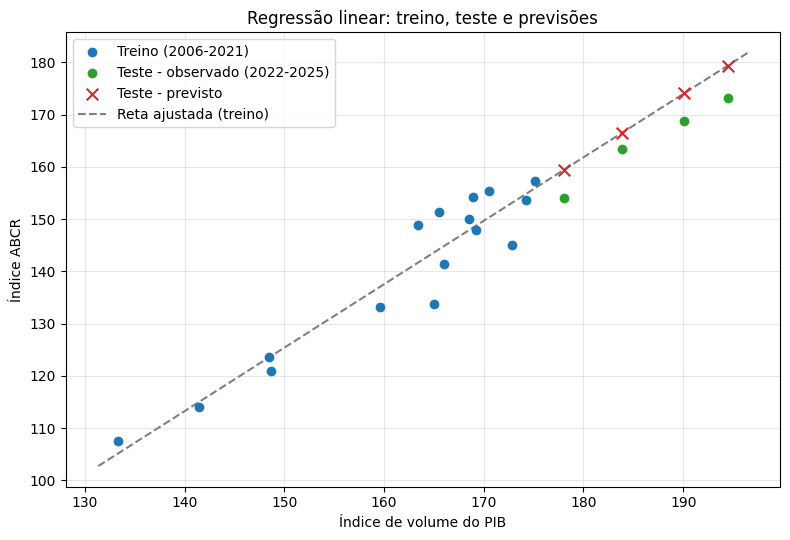

In [ ]:
y_pred = modelo.predict(X_teste)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(X_treino, y_treino, color="#1f77b4",
           label=f"Treino ({treino['Ano'].min()}-{treino['Ano'].max()})", zorder=3)
ax.scatter(X_teste, y_teste, color="#2ca02c",
           label=f"Teste - observado ({teste['Ano'].min()}-{teste['Ano'].max()})", zorder=3)
ax.scatter(X_teste, y_pred, color="#d62728", marker="x", s=70, label="Teste - previsto", zorder=3)
xs = np.linspace(df["PIB_indice"].min() - 2, df["PIB_indice"].max() + 2, 100)
ax.plot(xs, modelo.predict(pd.DataFrame({"PIB_indice": xs})), color="gray", ls="--",
        label="Reta ajustada (treino)")
ax.set_xlabel("Índice de volume do PIB")
ax.set_ylabel("Índice ABCR")
ax.set_title("Regressão linear: treino, teste e previsões")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

## Parte 5: Avaliação dos resultados (conjunto de teste)

Medimos o erro do modelo **apenas nos anos de teste**, que ele não viu durante o treino. As métricas são MAE, MSE, RMSE e R², e a tabela de comparação mostra o erro ano a ano.

In [ ]:
mae     = mean_absolute_error(y_teste, y_pred)
mse     = mean_squared_error(y_teste, y_pred)
r2_teste = r2_score(y_teste, y_pred)

metricas = pd.DataFrame({"Métrica": ["MAE", "MSE", "RMSE (raiz do MSE)", "R²"],
                         "Valor": [mae, mse, np.sqrt(mse), r2_teste]})
print(metricas.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

comparacao = pd.DataFrame({
    "Ano": teste["Ano"].values,
    "PIB_indice": X_teste["PIB_indice"].values,
    "ABCR_observado": y_teste.values,
    "ABCR_previsto": y_pred,
})
comparacao["Erro (previsto - observado)"] = comparacao["ABCR_previsto"] - comparacao["ABCR_observado"]
comparacao["Erro %"] = 100 * comparacao["Erro (previsto - observado)"] / comparacao["ABCR_observado"]
comparacao

           Métrica  Valor
               MAE  4.948
               MSE 25.939
RMSE (raiz do MSE)  5.093
                R²  0.485


,Ano,PIB_indice,ABCR_observado,ABCR_previsto,Erro (previsto - observado),Erro %
0,2022,178.05,154.12,159.460443,5.340443,3.465120
1,2023,183.82,163.49,166.468181,2.978181,1.821629
2,2024,190.10,168.88,174.095320,5.215320,3.088181
3,2025,194.45,173.12,179.378449,6.258449,3.615093


### Significado das métricas

- **MAE** (erro absoluto médio): em média, a previsão erra por cerca de **5 pontos** do Índice ABCR (na mesma unidade da série). Como o índice está em torno de 155–173 nos anos de teste, é um erro de uns 3%.
- **MSE** (erro quadrático médio): média dos erros ao quadrado, em pontos². Pune mais os erros grandes e é difícil de interpretar diretamente. Por isso mostramos também o RMSE (≈ 5,1), que volta à unidade original.
- **R²**: fração da variação dos dados de teste explicada pelo modelo. Aqui é cerca de **0,48**. O modelo explica menos da metade da variação em 2022–2025, bem abaixo do que a correlação de 0,96 sugeria.

### O modelo produziu estimativas próximas dos dados reais?

**Em ordem de grandeza, sim; em precisão, só em parte.** Os erros ficam entre cerca de 2% e 4% do valor real, mas têm **sempre o mesmo sinal**: o modelo **superestima** o fluxo nos quatro anos (o maior erro é em 2025, cerca de 6 pontos). Isso indica viés, e não ruído aleatório.

*(Os valores citados acima vêm da execução com os dados originais; confira-os com as tabelas geradas acima.)*

### Comparando observado x previsto

O gráfico abaixo mostra, ano a ano, a distância entre o fluxo real e o previsto pelo modelo.

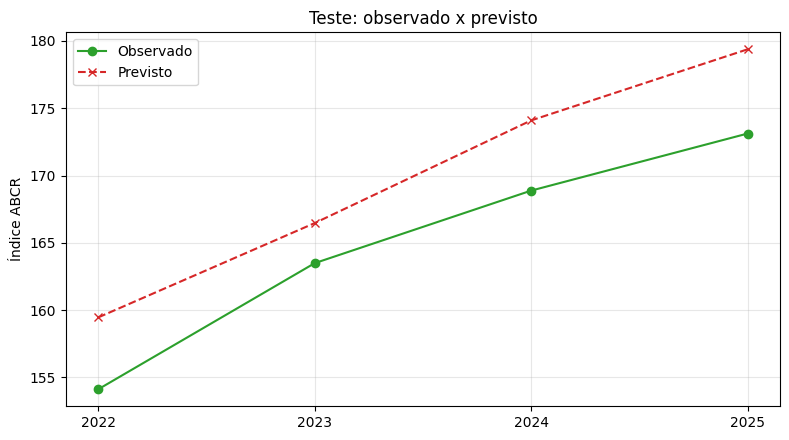

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(comparacao["Ano"], comparacao["ABCR_observado"], "o-", color="#2ca02c", label="Observado")
ax.plot(comparacao["Ano"], comparacao["ABCR_previsto"], "x--", color="#d62728", label="Previsto")
ax.set_xticks(comparacao["Ano"])
ax.set_ylabel("Índice ABCR")
ax.set_title("Teste: observado x previsto")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

### Diagnóstico: por que o R² do teste ficou abaixo da correlação?

Três verificações para entender o resultado:
1. O PIB do período de teste está **fora do intervalo** visto no treino (extrapolação)?
2. A **inclinação** da relação mudou entre os dois períodos?
3. O erro tem **viés** (erra sempre para o mesmo lado)?

In [ ]:
print("PIB no treino: de", round(X_treino["PIB_indice"].min(), 1), "a", round(X_treino["PIB_indice"].max(), 1))
print("PIB no teste : de", round(X_teste["PIB_indice"].min(), 1), "a", round(X_teste["PIB_indice"].max(), 1))
print()

for nome, d in [(f"Treino {treino['Ano'].min()}-{treino['Ano'].max()}", treino),
                (f"Teste {teste['Ano'].min()}-{teste['Ano'].max()}", teste)]:
    inclinacao, _ = np.polyfit(d["PIB_indice"], d["ABCR_indice"], 1)
    print(f"{nome}: inclinação = {inclinacao:.2f}")

print()
print(f"Erro médio no treino: {(modelo.predict(X_treino) - y_treino).mean():+.2f}")
print(f"Erro médio no teste : {(y_pred - y_teste).mean():+.2f}")

PIB no treino: de 133.3 a 175.1
PIB no teste : de 178.1 a 194.4

Treino 2006-2021: inclinação = 1.21
Teste 2022-2025: inclinação = 1.13

Erro médio no treino: -0.00
Erro médio no teste : +4.95


## Parte 6: Conclusões

1. **Existe relação forte entre PIB e fluxo de veículos.** A correlação entre os índices anuais de 2006–2025 é de 0,96. Mais atividade econômica anda junto com mais veículos nas rodovias.
2. **O modelo linear simples prevê só razoavelmente bem.** No teste (2022–2025), MAE ≈ 4,9 pontos, MSE ≈ 26,0 e R² ≈ 0,48. O erro é pequeno em termos percentuais, mas o R² mostra que o modelo explica menos da metade da variação do período.
3. **Por que o desempenho ficou abaixo da correlação?**
   - *Extrapolação:* o PIB de 2022–2025 (178 a 194) está **acima de tudo que o modelo viu no treino** (máx. ≈ 175). A reta do treino é estendida para uma região sem dados.
   - *Mudança de nível na relação:* a inclinação foi parecida nos dois períodos (≈ 1,21 no treino e ≈ 1,13 no teste), mas, em 2022–2025, o Índice ABCR ficou em média cerca de 5 pontos **abaixo** da reta do treino para o mesmo PIB. Ou seja, a relação parece ter se deslocado para baixo, o que explica o viés positivo nos quatro anos. Com só 4 pontos, essa leitura é uma hipótese e não uma conclusão firme.
   - *Poucos pontos de teste:* com só 4 observações, o R² é instável e sensível a qualquer erro.
   - *Tendência em comum e 2020:* os dois índices crescem ao longo do tempo e 2020 foge do padrão, o que pode distorcer o ajuste do treino.
4. **Correlação não é causalidade.** O resultado mostra associação, não que o PIB "cause" o fluxo (nem o contrário). Outros fatores, como população, frota, preço de combustível, pedágio e a composição do PIB, podem influenciar ambos.
5. **Melhorias possíveis** (fora do escopo): incluir mais variáveis, usar variações percentuais em vez de níveis ou validar com janelas móveis no tempo.

## Parte 7: Dificuldades encontradas e soluções

| Dificuldade | Solução |
|---|---|
| O CSV do SIDRA vem transposto (trimestres em colunas), com `;`, vírgula decimal, BOM e legendas no rodapé. | Leitura com o módulo `csv` (`delimiter=";"`, `encoding="utf-8-sig"`), seleção só das linhas necessárias, conversão de `,` para `.` e montagem de uma série por trimestre. |
| A planilha da ABCR tem várias abas (original e dessazonalizada) e blocos de colunas por região, com cabeçalho em várias linhas. | Uso da aba "(C) Original" (sem ajuste sazonal, como pede o enunciado) e seleção da coluna de Brasil/Total por posição. |
| As séries têm bases diferentes (PIB: média de 1995 = 100; ABCR: 1999 = 100) e frequências diferentes (trimestral x mensal). | Mantivemos cada número-índice na sua base (a regressão linear não exige a mesma base; muda só a interpretação do intercepto e da inclinação) e usamos médias anuais. Só entram anos completos nas duas séries; ago/2026 da ABCR ficou fora por ser ano incompleto. |
| Garantir que as médias anuais usem períodos completos. | Filtro de anos com 4 trimestres e 12 meses, e `assert` de que a tabela final não tem nulos. |
| R² de teste (0,48) bem menor que a correlação (0,96). | Diagnóstico de extrapolação e de mudança de inclinação entre os períodos (Parte 5), em vez de ajustar o modelo até "melhorar" a métrica. |
| Erro `FileNotFoundError` e `NameError` ao executar do zero (arquivos fora da pasta e variável `df` inexistente). | Função `obter_arquivo` (usa, baixa ou pede upload) e padronização do nome `df` em todo o notebook. |